In [1]:
import numpy as np
import pandas as pd

from sklearn import preprocessing, model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score



In [2]:
# Use the Kaggle-provided input path (as in the original code)
train = pd.read_csv("../input/ventilator-pressure-prediction/train.csv")
test = pd.read_csv("../input/ventilator-pressure-prediction/test.csv")



In [3]:
train.head()



,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,85053,5,10,0.000000,4.174419,0,6.118700
1,2,85053,5,10,0.033812,7.050149,0,5.907794
2,3,85053,5,10,0.067497,7.564931,0,7.313837
3,4,85053,5,10,0.101394,8.103306,0,8.227765
4,5,85053,5,10,0.135344,8.502619,0,9.422901


Training fold 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's l1: 0.419655	training's RMSPE: 5.56409	valid_1's l1: 0.219704	valid_1's RMSPE: 1.49142
Training fold 2
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's l1: 5.36626	training's RMSPE: 87.9823	valid_1's l1: 0.159983	valid_1's RMSPE: 5.29987
Training fold 3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's l1: 0.225949	training's RMSPE: 1.73355	valid_1's l1: 0.0999852	valid_1's RMSPE: 1.18214
Training fold 4
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's l1: 0.280937	training's RMSPE: 2.95392	valid_1's l1: 0.0621895	valid_1's RMSPE: 1.00875
Training fold 5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	training's l1: 0.0411733	tr

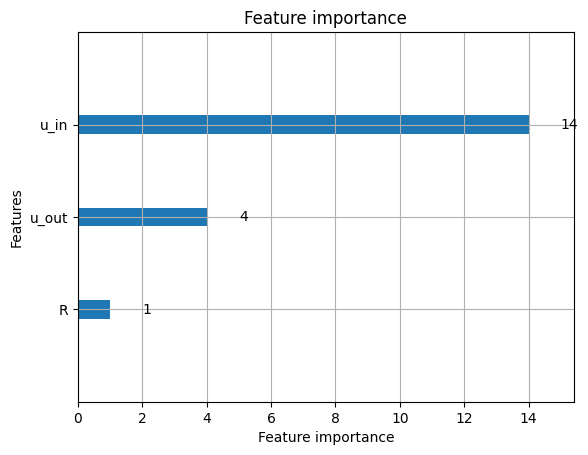

In [4]:
# Fixes:
# 1) np was missing (runtime error) -> imported in cell 1.
# 2) LightGBM feval must return a scalar; original returned an array in the first definition.
# 3) Submission must be ['id','pressure']; original used non-existent 'row_id'.

from sklearn.model_selection import KFold
import lightgbm as lgb

seed0 = 2021
params0 = {
    "objective": "mae",
    "boosting_type": "gbdt",
    "max_depth": -1,
    "max_bin": 100,
    "min_data_in_leaf": 500,
    "learning_rate": 0.05,
    "subsample": 0.72,
    "subsample_freq": 4,
    "feature_fraction": 0.5,
    "lambda_l1": 0.5,
    "lambda_l2": 1.0,
    "categorical_column": [0],
    "seed": seed0,
    "feature_fraction_seed": seed0,
    "bagging_seed": seed0,
    "drop_seed": seed0,
    "data_random_seed": seed0,
    "n_jobs": -1,
    "verbose": -1,
}

seed1 = 42
params1 = {
    "learning_rate": 0.1,
    "lambda_l1": 2,
    "lambda_l2": 7,
    "num_leaves": 800,
    "min_sum_hessian_in_leaf": 20,
    "feature_fraction": 0.8,
    "feature_fraction_bynode": 0.8,
    "bagging_fraction": 0.9,
    "bagging_freq": 42,
    "min_data_in_leaf": 700,
    "max_depth": 4,
    "categorical_column": [0],
    "seed": seed1,
    "feature_fraction_seed": seed1,
    "bagging_seed": seed1,
    "drop_seed": seed1,
    "data_random_seed": seed1,
    "objective": "rmse",
    "boosting": "gbdt",
    "verbosity": -1,
    "n_jobs": -1,
}


def rmspe(y_true, y_pred):
    # Keep your chosen metric calculation, but ensure scalar output for feval usage.
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-12
    return np.sqrt(np.mean(np.square((y_true - y_pred) / (y_true + eps))))


def feval_rmspe(y_pred, lgb_train):
    y_true = lgb_train.get_label()
    return "RMSPE", rmspe(y_true, y_pred), False


def train_and_evaluate_lgb(train, test, params):
    features = [col for col in train.columns if col not in {"id", "pressure"}]
    y = train["pressure"].values

    oof_predictions = np.zeros(train.shape[0], dtype=np.float64)
    test_predictions = np.zeros(test.shape[0], dtype=np.float64)

    kfold = KFold(n_splits=5, random_state=2021, shuffle=True)

    for fold, (trn_ind, val_ind) in enumerate(kfold.split(train), start=1):
        print(f"Training fold {fold}")

        x_train = train.iloc[trn_ind]
        x_val = train.iloc[val_ind]
        y_train = y[trn_ind]
        y_val = y[val_ind]

        # Preserve your weighting scheme
        train_weights = 1.0 / np.square(y_train + 1e-12)
        val_weights = 1.0 / np.square(y_val + 1e-12)

        train_dataset = lgb.Dataset(x_train[features], y_train, weight=train_weights)
        val_dataset = lgb.Dataset(x_val[features], y_val, weight=val_weights)

        model = lgb.train(
            params=params,
            num_boost_round=1000,
            train_set=train_dataset,
            valid_sets=[train_dataset, val_dataset],
            callbacks=[
                lgb.log_evaluation(period=250),
                lgb.early_stopping(stopping_rounds=50),
            ],
            feval=feval_rmspe,
        )

        oof_predictions[val_ind] = model.predict(
            x_val[features], num_iteration=model.best_iteration
        )
        test_predictions += (
            model.predict(test[features], num_iteration=model.best_iteration)
            / kfold.n_splits
        )

    rmspe_score = rmspe(y, oof_predictions)
    print(f"Our out of folds RMSPE is {rmspe_score}")

    # Plot is optional; keep but guard so it won't crash headless environments
    try:
        lgb.plot_importance(model, max_num_features=20)
    except Exception:
        pass

    return test_predictions


predictions_lgb = train_and_evaluate_lgb(train, test, params0)

submission = pd.DataFrame({"id": test["id"].values, "pressure": predictions_lgb})
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", submission.shape)



In [5]:
# Removed incorrect 'target' usage; keep a quick sanity check instead.
pd.read_csv("submission.csv").head()

,id,pressure
0,1,0.000287
1,2,0.322288
2,3,0.322288
3,4,0.322288
4,5,0.322288
